# ==========================================
# Predicción de Diabetes Tipo 2
# Notebook 01: Data Preprocessing
# ==========================================

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer

# Configuración gráfica
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [6]:
# Importar la base de datos
df = pd.read_csv("/content/sample_data/diabetes.csv")

In [9]:
# Dimensiones de la bd
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")

#Informacion general
df.info()

#Estadisticas descriptivas
df.describe()


Número de filas: 768
Número de columnas: 9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [25]:
# Valores faltantes
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [18]:
# Valores duplicados
print(f"Registros duplicados: {df.duplicated().sum()}")

Registros duplicados: 0


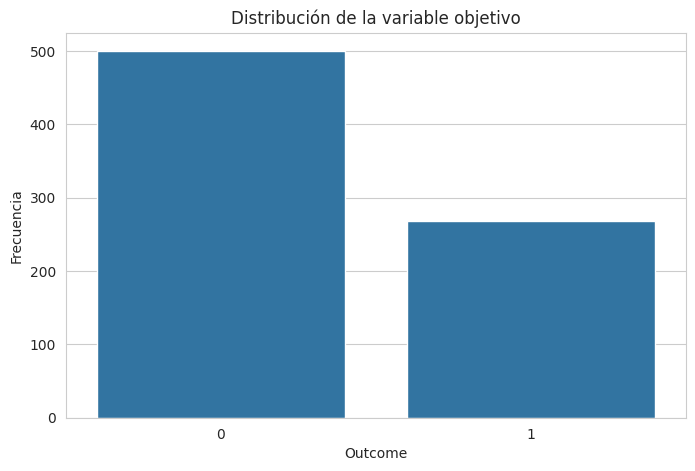

,count
Outcome,
0,500
1,268


In [21]:
# Distribución de la variable objetivo

sns.countplot(data=df, x="Outcome")

plt.title("Distribución de la variable objetivo")
plt.xlabel("Outcome")
plt.ylabel("Frecuencia")

plt.show()

df["Outcome"].value_counts()

In [23]:
#Identificacion de ceros en variables biológicas

columns_with_invalid_zeros = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for col in columns_with_invalid_zeros:
    print(f"{col}: {(df[col] == 0).sum()}")

print("Las variables SkinThickness e Insulin presentan una alta proporción de valores iguales a cero, los cuales son fisiológicamente improbables y serán tratados como valores faltantes implícitos.")

Glucose: 5
BloodPressure: 35
SkinThickness: 227
Insulin: 374
BMI: 11
Las variables SkinThickness e Insulin presentan una alta proporción de valores iguales a cero, los cuales son fisiológicamente improbables y serán tratados como valores faltantes implícitos.


In [24]:
#Reemplazar ceros con NaN

df_clean = df.copy()

columns_with_invalid_zeros = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

df_clean[columns_with_invalid_zeros] = (
    df_clean[columns_with_invalid_zeros]
    .replace(0, np.nan)
)

df_clean.isnull().sum()


,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [26]:
# Imputación de valores faltantes con la mediana

imputer = SimpleImputer(strategy="median")

df_clean[columns_with_invalid_zeros] = imputer.fit_transform(
    df_clean[columns_with_invalid_zeros]
)

df_clean.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [27]:
# Comprobación de la limpieza

df_clean.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


<Figure size 800x500 with 0 Axes>

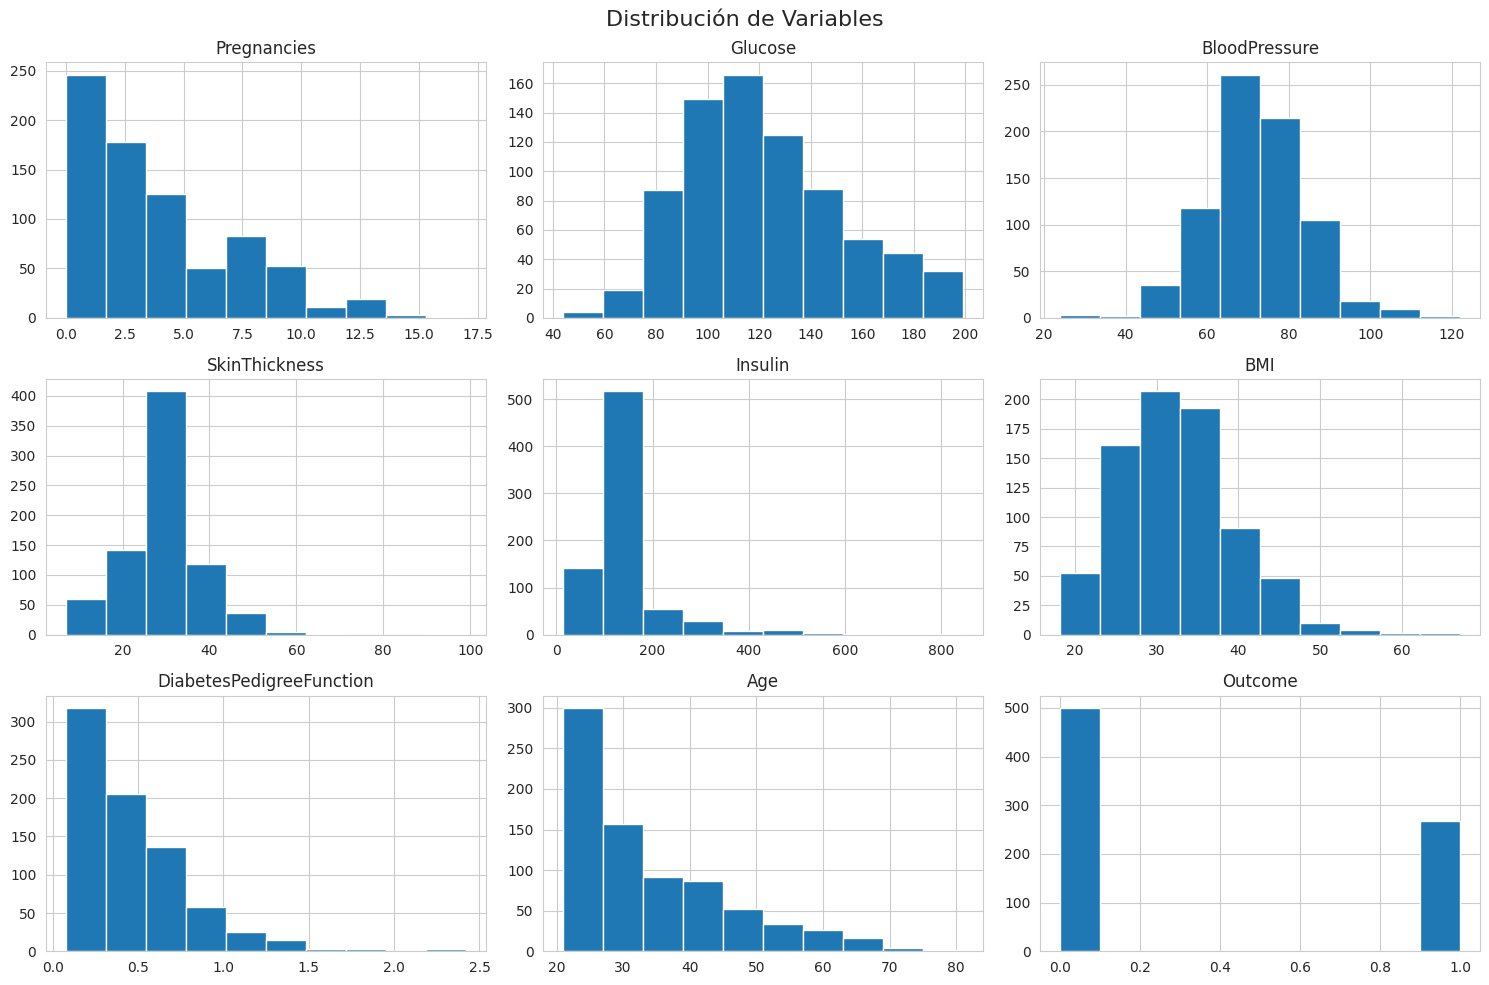

In [29]:
# Distribución de las variables numéricas

plt.suptitle("Distribución de Variables", fontsize=16)
plt.tight_layout()

plt.show()

df_clean.hist(figsize=(15,10))

plt.suptitle("Distribución de Variables", fontsize=16)
plt.tight_layout()

plt.show()

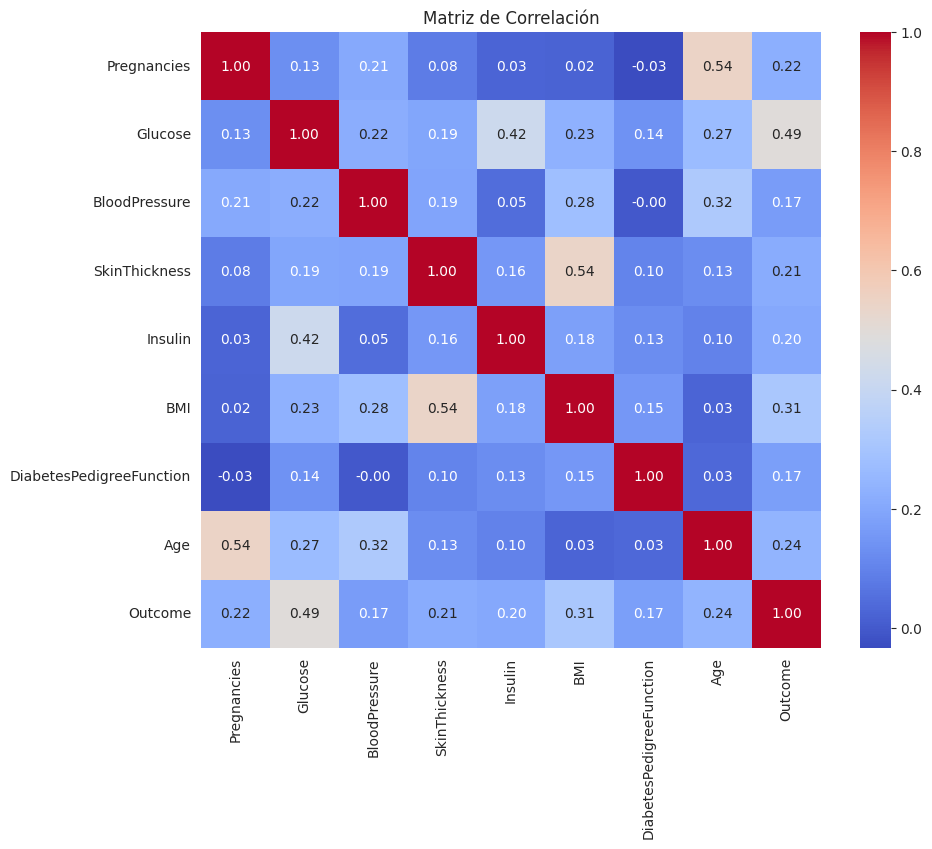

La concentración de glucosa presenta la mayor asociación con la presencia de diabetes, seguida por el índice de masa corporal (BMI) y la edad. Estos resultados son consistentes con factores de riesgo ampliamente descritos en la literatura médica.


In [31]:
# Matriz de correlación

plt.figure(figsize=(10,8))

sns.heatmap(
    df_clean.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Matriz de Correlación")
plt.show()

print("La concentración de glucosa presenta la mayor asociación con la presencia de diabetes, seguida por el índice de masa corporal (BMI) y la edad. Estos resultados son consistentes con factores de riesgo ampliamente descritos en la literatura médica.")

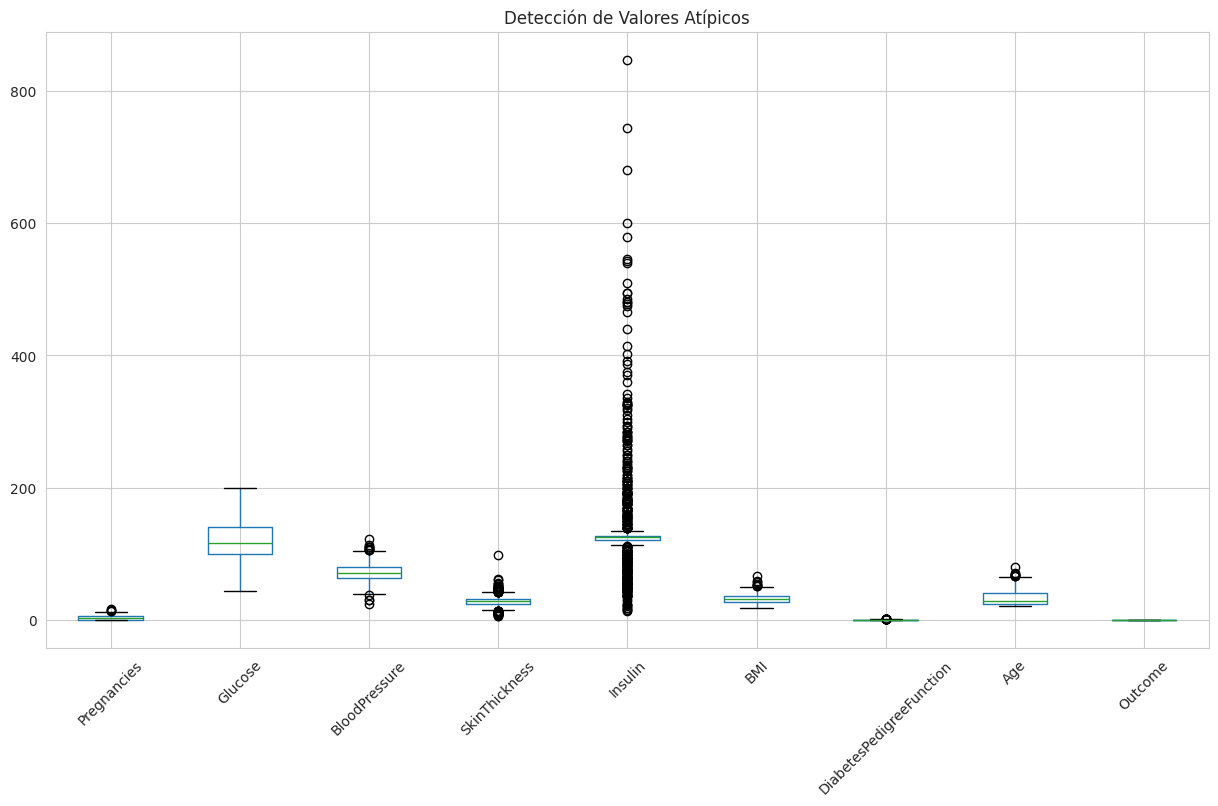

Se identificaron valores atípicos en múltiples variables, especialmente en Insulin. Debido a que estos valores pueden representar variabilidad biológica real y el tamaño del conjunto de datos es relativamente pequeño, no se realizó eliminación de observaciones durante la etapa de preprocesamiento.


In [33]:
#Boxplots para detectar valores atípicos

plt.figure(figsize=(15,8))

df_clean.boxplot()

plt.title("Detección de Valores Atípicos")
plt.xticks(rotation=45)

plt.show()

print("Se identificaron valores atípicos en múltiples variables, especialmente en Insulin. Debido a que estos valores pueden representar variabilidad biológica real y el tamaño del conjunto de datos es relativamente pequeño, no se realizó eliminación de observaciones durante la etapa de preprocesamiento.")

In [34]:
df_clean.to_csv("diabetes_clean.csv", index=False)

print("Dataset limpio guardado correctamente.")

Dataset limpio guardado correctamente.
